In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import json
import hashlib
from pathlib import Path
from collections import Counter
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # 습관처럼 무조건
print(device)

print(torch.__version__)

OUT = Path("outputs/garbage")
df = pd.read_csv(OUT / "metrics" / "index.csv")

print(f"입력: {len(df):,}행 / {df['label'].nunique()}클래스")
print(df["label"].value_counts().to_string())

cuda
2.11.0+cu128
입력: 15,515행 / 12클래스
label
clothes        5325
shoes          1977
paper          1050
biological      985
battery         945
cardboard       891
plastic         865
white-glass     775
metal           769
trash           697
green-glass     629
brown-glass     607


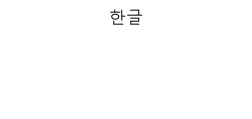

In [4]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize = (3, 1))
plt.title("한글")
plt.axis("off")
plt.show()

In [5]:
def file_md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

df["md5"] = [file_md5(p) for p in df["path"]]

dup_mask = df.duplicated(subset="md5", keep="first")
n_dup = int(dup_mask.sum())

print(f"완전 중복 파일: {n_dup}개")

if n_dup:
    # 중복이 클래스 경계를 넘나드는지 확인 — 넘나든다면 라벨 자체가 모순
    g = df[df.duplicated(subset="md5", keep=False)].groupby("md5")["label"].nunique()
    cross = int((g > 1).sum())
    print(f"  이 중 서로 다른 클래스에 걸친 중복: {cross}건")
    if cross:
        print("  → 동일 이미지가 두 클래스에 라벨링된 것이므로 반드시 제거 대상입니다.")
    print()
    print("제거되는 파일의 클래스 분포:")
    print(df.loc[dup_mask, "label"].value_counts().to_string())

df = df[~dup_mask].drop(columns="md5").reset_index(drop=True)
print(f"\n중복 제거 후: {len(df):,}행")

완전 중복 파일: 19개
  이 중 서로 다른 클래스에 걸친 중복: 3건
  → 동일 이미지가 두 클래스에 라벨링된 것이므로 반드시 제거 대상입니다.

제거되는 파일의 클래스 분포:
label
green-glass    15
white-glass     3
clothes         1

중복 제거 후: 15,496행


In [6]:
classes = sorted(df["label"].unique())
label_map = {c: i for i, c in enumerate(classes)}

df["label_idx"] = df["label"].map(label_map)

with open(OUT / "metrics" / "label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

print("클래스 인덱스")
for c, i in label_map.items():
    print(f"  {i:2d}  {c}")

클래스 인덱스
   0  battery
   1  biological
   2  brown-glass
   3  cardboard
   4  clothes
   5  green-glass
   6  metal
   7  paper
   8  plastic
   9  shoes
  10  trash
  11  white-glass


In [7]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED, shuffle=True)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED, shuffle=True)

train_df = train_df.assign(split="train")
val_df   = val_df.assign(split="val")
test_df  = test_df.assign(split="test")

split_df = (pd.concat([train_df, val_df, test_df])
              .sort_values(["split", "label"])
              .reset_index(drop=True))

print(f"train {len(train_df):,}  |  val {len(val_df):,}  |  test {len(test_df):,}")
print(f"합계   {len(split_df):,}  (원본 {len(df):,})")
assert len(split_df) == len(df), "분할 과정에서 행 수가 바뀌었습니다"
assert split_df["path"].nunique() == len(split_df), "동일 경로가 중복 배정되었습니다"

train 10,847  |  val 2,324  |  test 2,325
합계   15,496  (원본 15,496)


In [8]:
pivot = split_df.pivot_table(index="label", columns="split",
                             values="path", aggfunc="count")
pivot = pivot[["train", "val", "test"]]
pivot["total"] = pivot.sum(axis=1)

ratio = pivot[["train", "val", "test"]].div(pivot["total"], axis=0) * 100
ratio.columns = ["train%", "val%", "test%"]

print(pd.concat([pivot, ratio.round(1)], axis=1).to_string())
print()
print("전체 비율(%):",
      (pivot[["train", "val", "test"]].sum() / pivot["total"].sum() * 100).round(1).to_dict())

             train  val  test  total  train%  val%  test%
label                                                    
battery        661  142   142    945    69.9  15.0   15.0
biological     689  148   148    985    69.9  15.0   15.0
brown-glass    425   91    91    607    70.0  15.0   15.0
cardboard      624  133   134    891    70.0  14.9   15.0
clothes       3727  798   799   5324    70.0  15.0   15.0
green-glass    430   92    92    614    70.0  15.0   15.0
metal          538  116   115    769    70.0  15.1   15.0
paper          735  157   158   1050    70.0  15.0   15.0
plastic        606  130   129    865    70.1  15.0   14.9
shoes         1384  296   297   1977    70.0  15.0   15.0
trash          488  105   104    697    70.0  15.1   14.9
white-glass    540  116   116    772    69.9  15.0   15.0

전체 비율(%): {'train': 70.0, 'val': 15.0, 'test': 15.0}


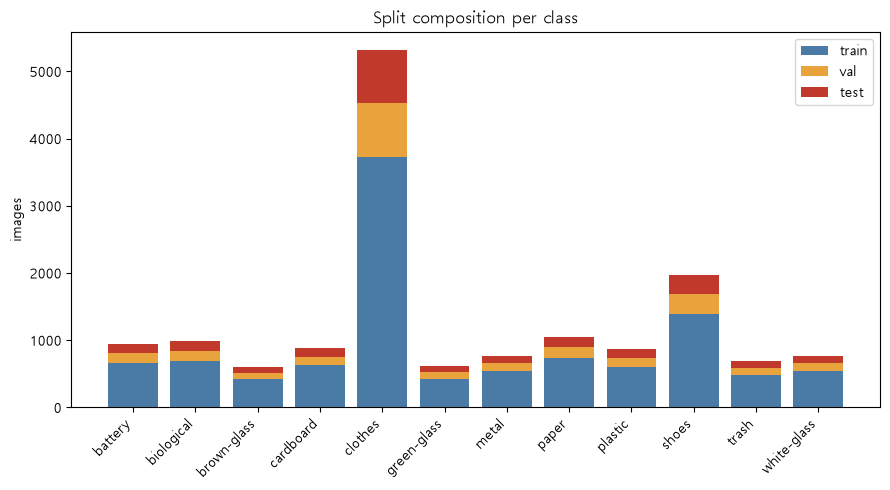

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(pivot))
colors = {"train": "#4a7ba7", "val": "#e8a33d", "test": "#c0392b"}

for s in ["train", "val", "test"]:
    ax.bar(pivot.index, pivot[s], bottom=bottom, label=s, color=colors[s])
    bottom += pivot[s].values

ax.set_ylabel("images")
ax.set_title("Split composition per class")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT / "figures" / "06_split.png", dpi=150)
plt.show()

In [10]:
train_counts = train_df["label"].value_counts().reindex(classes)
n_samples, n_classes = len(train_df), len(classes)

# sklearn 'balanced' 공식
class_weight = n_samples / (n_classes * train_counts)

cw = pd.DataFrame({
    "label":        classes,
    "label_idx":    [label_map[c] for c in classes],
    "train_count":  train_counts.values,
    "class_weight": class_weight.values.round(4),
}).sort_values("label_idx")

cw.to_csv(OUT / "metrics" / "class_weights.csv", index=False, encoding="utf-8")
print(cw.to_string(index=False))
print(f"\n가중치 범위: {class_weight.min():.3f} ~ {class_weight.max():.3f}")

      label  label_idx  train_count  class_weight
    battery          0          661        1.3675
 biological          1          689        1.3119
brown-glass          2          425        2.1269
  cardboard          3          624        1.4486
    clothes          4         3727        0.2425
green-glass          5          430        2.1021
      metal          6          538        1.6801
      paper          7          735        1.2298
    plastic          8          606        1.4916
      shoes          9         1384        0.6531
      trash         10          488        1.8523
white-glass         11          540        1.6739

가중치 범위: 0.243 ~ 2.127


In [11]:
# 03/04 노트북에서 쓸 형태 — 참고용 스니펫
print("""
# ── (A) 손실 가중치 방식 ──────────────────────────────
cw = pd.read_csv("outputs/garbage/metrics/class_weights.csv").sort_values("label_idx")
w  = torch.tensor(cw["class_weight"].values, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=w)

# ── (B) 샘플러 방식 ───────────────────────────────────
from torch.utils.data import WeightedRandomSampler
per_class = cw.set_index("label_idx")["class_weight"].to_dict()
sample_w  = [per_class[i] for i in train_dataset.targets]
sampler   = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler, ...)
# 주의: sampler를 쓰면 shuffle=True를 함께 줄 수 없습니다.
""")


# ── (A) 손실 가중치 방식 ──────────────────────────────
cw = pd.read_csv("outputs/garbage/metrics/class_weights.csv").sort_values("label_idx")
w  = torch.tensor(cw["class_weight"].values, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=w)

# ── (B) 샘플러 방식 ───────────────────────────────────
from torch.utils.data import WeightedRandomSampler
per_class = cw.set_index("label_idx")["class_weight"].to_dict()
sample_w  = [per_class[i] for i in train_dataset.targets]
sampler   = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler, ...)
# 주의: sampler를 쓰면 shuffle=True를 함께 줄 수 없습니다.



In [12]:
SIZE = 128          # 통계 추정용 축소 크기 — 224로 해도 값은 거의 동일
psum, psum_sq, npix = np.zeros(3), np.zeros(3), 0

for i, p in enumerate(train_df["path"]):
    img = cv2.imread(p, cv2.IMREAD_COLOR)
    if img is None:
        continue
    img = cv2.cvtColor(cv2.resize(img, (SIZE, SIZE)), cv2.COLOR_BGR2RGB)
    x = img.astype(np.float64) / 255.0
    psum    += x.sum(axis=(0, 1))
    psum_sq += (x ** 2).sum(axis=(0, 1))
    npix    += x.shape[0] * x.shape[1]
    if (i + 1) % 2000 == 0:
        print(f"  {i + 1:,} / {len(train_df):,}")

mean = psum / npix
std  = np.sqrt(psum_sq / npix - mean ** 2)

stats = {
    "dataset_mean": [round(float(v), 4) for v in mean],
    "dataset_std":  [round(float(v), 4) for v in std],
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std":  [0.229, 0.224, 0.225],
    "computed_on":   "train split only",
    "n_images":      int(len(train_df)),
}

with open(OUT / "metrics" / "norm_stats.json", "w", encoding="utf-8") as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)

print("\ndataset mean:", stats["dataset_mean"])
print("dataset std :", stats["dataset_std"])
print("imagenet    :", stats["imagenet_mean"], stats["imagenet_std"])

  2,000 / 10,847
  4,000 / 10,847
  6,000 / 10,847
  8,000 / 10,847
  10,000 / 10,847

dataset mean: [0.6579, 0.6158, 0.5855]
dataset std : [0.2801, 0.2918, 0.3057]
imagenet    : [0.485, 0.456, 0.406] [0.229, 0.224, 0.225]


In [13]:
split_df[["path", "label", "label_idx", "split"]].to_csv(
    OUT / "metrics" / "split.csv", index=False, encoding="utf-8")

# ── leakage 최종 확인 ──
sets = {s: set(split_df.loc[split_df.split == s, "path"]) for s in ["train", "val", "test"]}
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    inter = sets[a] & sets[b]
    print(f"{a:5s} ∩ {b:5s} : {len(inter)}건", "OK" if not inter else "!!! 겹침 발생")

# ── 파일 실재 여부 표본 확인 ──
missing = [p for p in split_df["path"].sample(300, random_state=SEED) if not Path(p).exists()]
print(f"\n표본 300개 중 없는 파일: {len(missing)}개")

print(f"\nsplit.csv 저장 완료 — {len(split_df):,}행")
print(split_df.head(3).to_string(index=False))

train ∩ val   : 0건 OK
train ∩ test  : 0건 OK
val   ∩ test  : 0건 OK

표본 300개 중 없는 파일: 0개

split.csv 저장 완료 — 15,496행
  label                                               path  label_idx split
battery data\garbage_classification\battery\battery523.jpg          0  test
battery data\garbage_classification\battery\battery308.jpg          0  test
battery data\garbage_classification\battery\battery341.jpg          0  test
